# Variational Autoencoder (VAE) 


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FOLDERNAME = 'training_zen/phase2/assignment2_1'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME

Mounted at /content/drive
/content/drive/My Drive/training_zen/phase2/assignment2_1


In [2]:
print(FOLDERNAME)

training_zen/phase2/assignment2_1


## Datasets download

In [ ]:
# Move to dataset directory and run the downloader bash script
# %cd dataset
# !bash get_dataset.sh
# # Return back to the project root directory
# %cd ..

/content/drive/My Drive/training_zen/phase2/assignment2_1/dataset
Creating data folder...
100% 9.91M/9.91M [00:01<00:00, 5.15MB/s]
100% 28.9k/28.9k [00:00<00:00, 135kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.32MB/s]
100% 4.54k/4.54k [00:00<00:00, 15.0MB/s]
Preparing CelebA directory...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=0B7EVK8r0v71pY0NSN1gyOTB1ZzQ

but Gdown can't. Please check connections and permissions.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarn

In [13]:
!pip install -q --upgrade-strategy only-if-needed -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.4 MB/s eta 0:00:00


In [11]:
!pip install IPython==8.18.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.2/808.2 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.5 MB/s eta 0:00:0000:01
  Attempting uninstall: IPython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.18.1 which is incompatible.


In [12]:
%load_ext autoreload
%autoreload 2


## Tests

Run unit tests to ensure dataset splits, layer activation shapes, gradient flows, and checkpoint saving mechanics work correctly.

In [7]:
!python -m unittest discover -s test -p "test_*.py"


=== RUNNING CELEBA DATASET FALLBACK TEST ===
Successfully loaded 10 CelebA images using FlatImageDataset fallback.
CelebA Mock Train split items: 6
CelebA Mock Val split items: 2
CelebA Mock Test split items: 2
Loaded batch shape: torch.Size([2, 3, 128, 128])
Batch value range: [-0.216, 0.106]
Logging 3 sample images:
  - Item 1: Shape=torch.Size([3, 128, 128]), Mean=-0.0719, Std=0.1124
  - Item 2: Shape=torch.Size([3, 128, 128]), Mean=-0.0667, Std=0.1323
.
=== RUNNING MNIST DATASET TEST ===
100% 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100% 28.9k/28.9k [00:00<00:00, 134kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100% 4.54k/4.54k [00:00<00:00, 15.5MB/s]
MNIST Train split items: 54000
MNIST Val split items: 6000
MNIST Test split items: 10000
Loaded batch shape: torch.Size([4, 1, 128, 128])
Batch value range: [-1.000, 1.000]
Logging 3 sample images:
  - Item 1: Shape=torch.Size([1, 128, 128]), Mean=-0.7123, Std=0.6361
  - Item 2: Shape=torch.Size([1, 128, 128]), Mean=-0.7978, Std=0.4758
 

In [14]:

import wandb
wandb.login()

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [15]:
!nvidia-smi

Sat Jun  6 01:16:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Train


This runs the main training loop. It prints progress via tqdm and logs all losses and grid images to Weights & Biases (W&B).

In [16]:
!python main.py --config config.yaml

======= Training Config Override =======
base_vae:
  hidden_dims:
  - 32
  - 64
  - 128
  - 256
  in_channels: 1
  latent_dim: 128
batch_size: 64
data_dir: ./data
dataset: mnist
image_size: 128
num_workers: 2
training:
  checkpoint_dir: ./checkpoints
  device: cuda
  epochs: 20
  fid_interval: 5
  learning_rate: 0.001
  num_fid_samples: 500
  sample_interval: 5
  weight_decay: 1.0e-05
val_split_ratio: 0.1
vq_vae:
  embedding_dim: 32
  hidden_dims:
  - 32
  - 64
  - 128
  num_embeddings: 64

Using device: cuda
Initializing Weights & Biases (wandb) run...
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: tam-vd230064 (tam-vd230064-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run 2iw0mdg6 (0.0s)
wandb: ⣻ setting up run 2iw0mdg6 (0.0s)
wandb: ⣽ setting up run 2iw0mdg6 (0.0s)
wandb: ⣾ setting up run 2iw0mdg6 (0.0s)
wandb: ⣷ setting up ru

Infer

Generate random samples from the latent space prior using the saved best checkpoint weights.

In [17]:
!python infer/infer_baseline_vae.py --checkpoint checkpoints/best_checkpoint.pth --mode sample --num_samples 16 --output_dir colab_results

Running inference on: cuda
Configuration successfully loaded from the checkpoint metadata.
Model initialized and checkpoint weights successfully loaded.
Generating 16 samples from latent prior space...
Successfully generated grid saved to: colab_results/generation_samples.png
Individual samples saved to: colab_results/samples/


Visualize

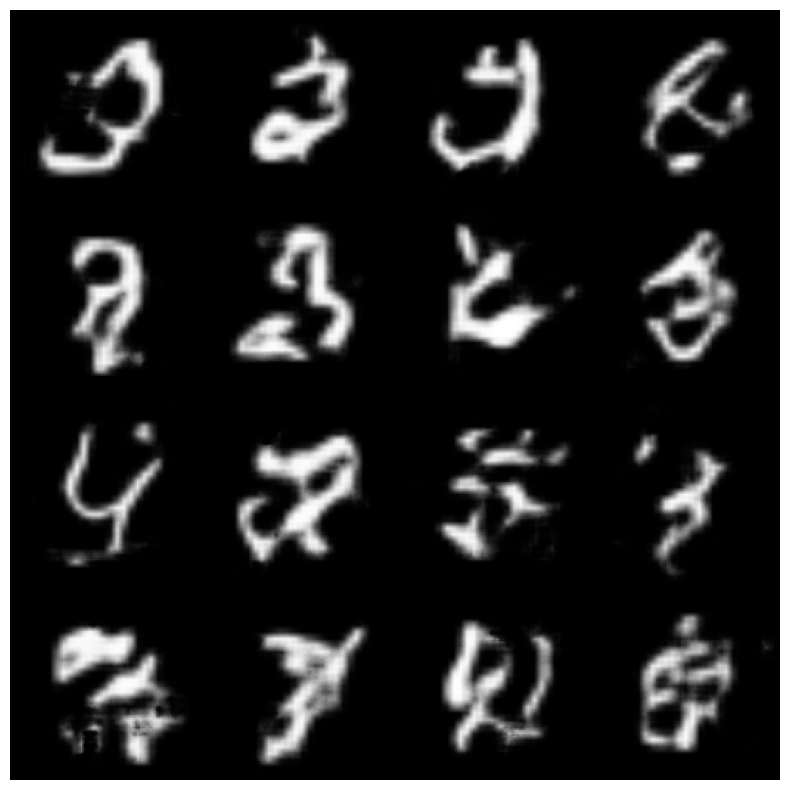

In [18]:
import os
import matplotlib.pyplot as plt
from PIL import Image

grid_path = 'colab_results/generation_samples.png'
if os.path.exists(grid_path):
    img = Image.open(grid_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("[!] Run the inference cell above first to generate samples!")